In [1]:
from config_loader import CONFIG
from loggerplusplus import LoggerManager, LogLevels, LoggerConfig, Logger, logger_colors

LoggerManager.enable_files_logs_monitoring_only_for_one_logger = True
LoggerManager.global_config = LoggerConfig.from_kwargs(
    colors=logger_colors.ClassicColors,
    path="logs",
    # LogLevels
    decorator_log_level=LogLevels.DEBUG,
    print_log_level=LogLevels.INFO,
    file_log_level=LogLevels.DEBUG,
    # Loggers Output
    print_log=True,
    write_to_file=True,
    # Monitoring
    display_monitoring=False,
    files_monitoring=False,
    file_size_unit="Go",
    disk_alert_threshold_percent=0.8,
    log_files_size_alert_threshold_percent=0.2,
    max_log_file_size=1.0,
    # Placement
    identifier_max_width=15,
    filename_lineno_max_width=15,
)

from arena import ShowArena
from geometry import OrientedPoint
from brains import MainBrain
from controllers import RollingBasisDummy, RollingBasis
from movement_manager import MovementManager
from sensors import LidarDummy, Lidar
from movement_manager import MovementManager, GoToParams
from rolling_basis_handler import SpeedProfile
from rolling_basis_handler import RollingBasisHandler, RollingBasisCommand


In [2]:
logger_grid_manager = Logger(
    identifier="GridManager",
    follow_logger_manager_rules=True,
)
logger_show_arena = Logger(
    identifier="ShowArena",
    follow_logger_manager_rules=True,
)
logger_movement_manager = Logger(
    identifier="MovementManager",
    follow_logger_manager_rules=True,
)
logger_rolling_basis_handler = Logger(
    identifier="RollingBasisHandler",
    follow_logger_manager_rules=True,
)
logger_path_finder = Logger(
    identifier="PathFinder",
    follow_logger_manager_rules=True,
)

arena = ShowArena(
    logger=logger_show_arena,
    border_buffer=2,
    obstacle_buffer=1,
    chunk_size=5,
    forbidden_cover_threshold=0.1,
    grid_manager_logger=logger_grid_manager,
)

arena.update(
    ally_position=OrientedPoint(20, 20, 0),
    lidar_scan_polars=[]
)

movement_manager = MovementManager(
    logger=logger_movement_manager,
    rolling_basis_handler_logger=logger_rolling_basis_handler,
    path_finder_logger=logger_path_finder,
    movement_resolution=1,
    arena=arena,
)

19:11:37.435393 -> [   ShowArena   ] [  arena.py  :102]  WARNING   | The border buffer is not a multiple of the chunk size -> the not walkable area will not be aligned with the grid
19:11:37.437446 -> [   ShowArena   ] [  arena.py  :108]  WARNING   | The obstacle buffer is not a multiple of the chunk size -> the not walkable area will not be aligned with the grid
19:11:38.797932 -> [   ShowArena   ] [  arena.py  :172]    INFO    | ShowArena initialized.


In [3]:
speed_profile: SpeedProfile = SpeedProfile(
    max_linear_speed=20.0,  # cm/s
    max_angular_speed=6.0,  # rad/s
    max_linear_acceleration=3.0,  # cm/s^2
    max_angular_acceleration=1.0,  # rad/s^2
    max_linear_deceleration=10,  # cm/s^2
    max_angular_deceleration=1.0,  # rad/s^2
)
go_to_params = GoToParams(
    initial_linear_speed=0,
    initial_angular_speed=0,
    speed_profile=speed_profile,
    goal=OrientedPoint(250, 140),
    acs_distance=10,
    path_finder_recompute_distance=80,
    timeout=-1.0,
    is_mandatory=False,
    smooth_trajectory=True,
    goal_tolerance=0.1,
)

In [4]:
movement_manager.go_to(params=go_to_params)

19:11:38.965152 -> [MovementManager] [movement_m..:153]  WARNING   | A movement is already in progress and a new one is requested.
19:11:38.970160 -> [MovementManager] [movement_m..:109]    INFO    | Using only static grid for path finding


In [5]:
cmd: RollingBasisCommand = movement_manager.handle_go_to()
print(cmd)

theta1 0.7853981633974483 theta2 0.7853981633974483 theta 0.7853981633974483
RollingBasisCommand(position=POINT (23.206984419334255 23.206984419334255), theta: 0.7853981633974483, linear_speed=0.03222227096557617, angular_speed=0.0)


Total duration: 18.081208831828448
theta1 0.7853981633974483 theta2 0.7853981633974483 theta 0.7853981633974483
Temps: 0.00s, Linéaire: 0.08, Angulaire: 0.00, Position: (23.21, 23.21, 0.79)
theta1 0.7853981633974483 theta2 0.7853981633974483 theta 0.7853981633974483
Temps: 0.50s, Linéaire: 1.58, Angulaire: 0.00, Position: (22.91, 22.91, 0.79)
theta1 0.7853981633974483 theta2 0.7853981633974483 theta 0.7853981633974483
Temps: 1.00s, Linéaire: 3.09, Angulaire: 0.00, Position: (23.50, 23.50, 0.79)
theta1 0.7853981633974483 theta2 0.7853981633974483 theta 0.7853981633974483
Temps: 1.51s, Linéaire: 4.60, Angulaire: 0.00, Position: (24.96, 24.96, 0.79)
theta1 0.7853981633974483 theta2 0.7853981633974483 theta 0.7853981633974483
Temps: 2.01s, Linéaire: 6.10, Angulaire: 0.00, Position: (27.31, 27.31, 0.79)
theta1 0.7853981633974483 theta2 0.7853981633974483 theta 0.7853981633974483
Temps: 2.51s, Linéaire: 7.61, Angulaire: 0.00, Position: (29.21, 29.21, 0.79)
theta1 0.7853981633974483 theta2 0.

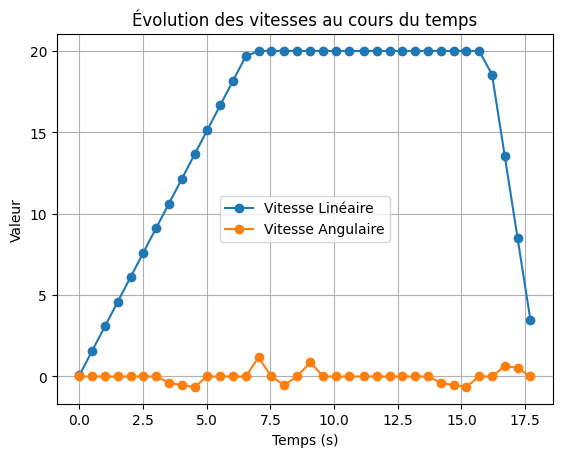

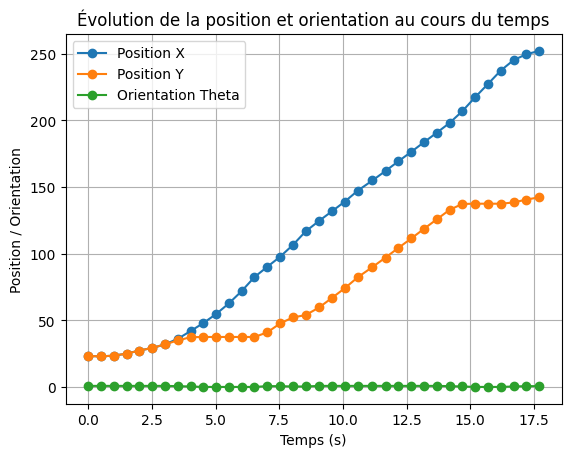

In [6]:
import time
import random
import matplotlib.pyplot as plt
from dataclasses import dataclass

def boucle_intervallee(duree_totale: float, intervalle: float):
    """Exécute une boucle pendant une durée donnée avec un intervalle régulier."""
    start_time = time.time()

    temps = []
    linear_speeds = []
    angular_speeds = []
    x_positions = []
    y_positions = []
    thetas = []
    
    while (time.time() - start_time) < duree_totale:
        elapsed_time = time.time() - start_time
        command = movement_manager.handle_go_to()
        linear_speed, angular_speed, position = command.get_command()
        
        print(f"Temps: {elapsed_time:.2f}s, Linéaire: {linear_speed:.2f}, Angulaire: {angular_speed:.2f}, Position: ({position.x:.2f}, {position.y:.2f}, {position.theta:.2f})")
        
        temps.append(elapsed_time)
        linear_speeds.append(linear_speed)
        angular_speeds.append(angular_speed)
        x_positions.append(position.x)
        y_positions.append(position.y)
        thetas.append(position.theta)
        
        time.sleep(intervalle)
    
    plt.figure()
    plt.plot(temps, linear_speeds, marker='o', linestyle='-', label='Vitesse Linéaire')
    plt.plot(temps, angular_speeds, marker='o', linestyle='-', label='Vitesse Angulaire')
    plt.xlabel("Temps (s)")
    plt.ylabel("Valeur")
    plt.title("Évolution des vitesses au cours du temps")
    plt.legend()
    plt.grid()
    plt.show()
    
    plt.figure()
    plt.plot(temps, x_positions, marker='o', linestyle='-', label='Position X')
    plt.plot(temps, y_positions, marker='o', linestyle='-', label='Position Y')
    plt.plot(temps, thetas, marker='o', linestyle='-', label='Orientation Theta')
    plt.xlabel("Temps (s)")
    plt.ylabel("Position / Orientation")
    plt.title("Évolution de la position et orientation au cours du temps")
    plt.legend()
    plt.grid()
    plt.show()

# Exécuter la boucle pendant 10 secondes avec un intervalle de 1 seconde
print(f"Total duration: {movement_manager.rolling_basis_handler.total_duration}")
boucle_intervallee(duree_totale=movement_manager.rolling_basis_handler.total_duration, intervalle=0.5)